In [45]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

In [46]:
df = pd.read_csv('creditcard_fraud_detection.csv')  # use this if uploaded manually
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


The dataset was successfully loaded and inspected to understand its structure, dimensionality, and feature types. It consists of anonymized transaction features (V1–V28), along with ‘Time’, ‘Amount’, and a binary ‘Class’ label indicating fraudulent (1) or legitimate (0) transactions. Initial inspection confirms that the dataset is numerical and suitable for machine learning models without requiring categorical encoding.

In [47]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  flo

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Class
0    284315
1       492
Name: count, dtype: int64


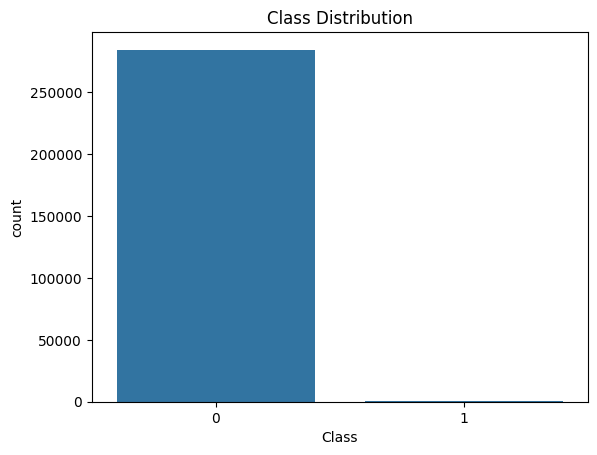

In [48]:
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

The dataset exhibits a highly imbalanced class distribution, where fraudulent transactions represent only a very small fraction of the total observations. This imbalance poses a significant challenge for machine learning models, as they may become biased toward predicting the majority class. Therefore, specialized techniques such as resampling and appropriate evaluation metrics are necessary.

In [49]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


No missing values were detected in the dataset, indicating that the dataset is clean and does not require imputation. This ensures that all features can be directly utilized for model training without introducing bias or uncertainty from missing data handling techniques.

In [50]:
print(df.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


#Feature Correlation Heatmap

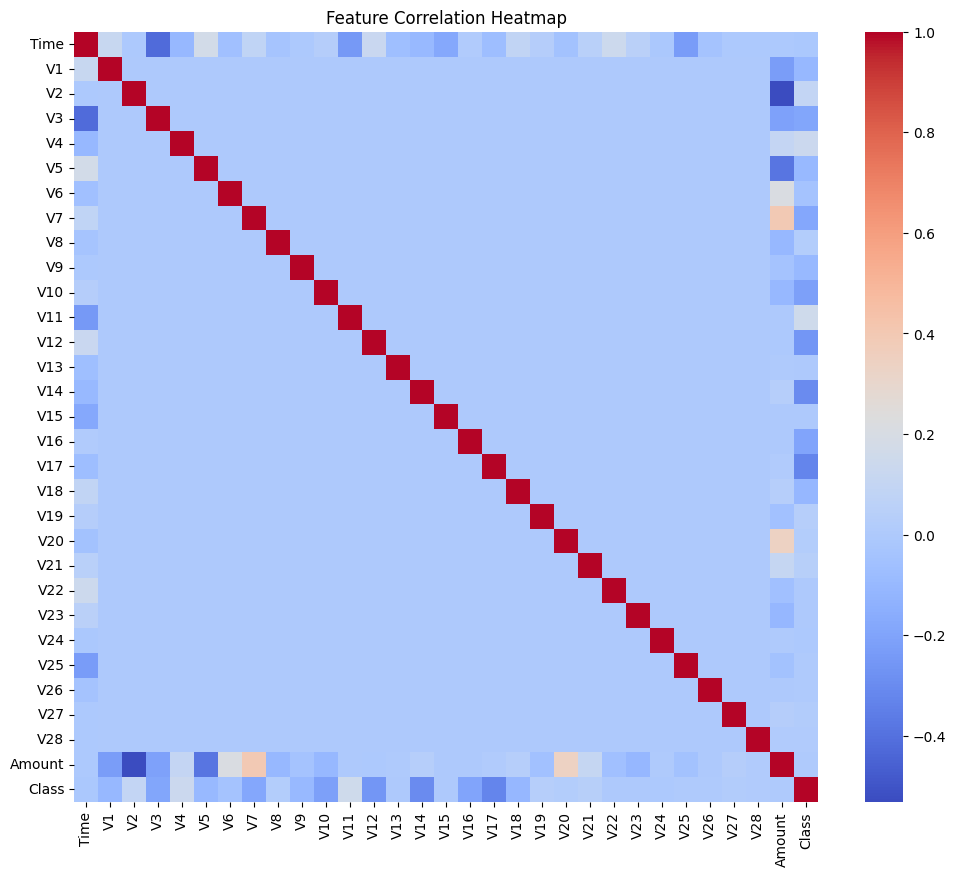

In [51]:
plt.figure(figsize=(12,10))

corr = df.corr()

sns.heatmap(corr, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

The correlation heatmap reveals the relationships between features and the target variable. Most features show low correlation with each other due to prior PCA transformation, which reduces multicollinearity. However, certain features demonstrate relatively higher correlation with the target class, indicating their potential importance in distinguishing fraudulent transactions.

#Fraud Feature Correlation with Target

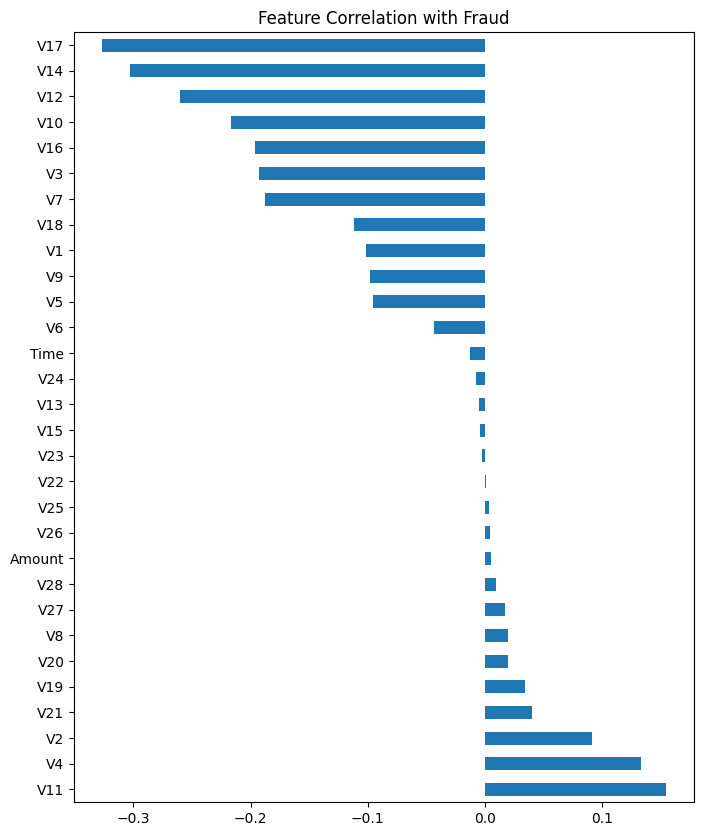

In [52]:
corr_target = df.corr()['Class'].sort_values(ascending=False)

plt.figure(figsize=(8,10))

corr_target.drop('Class').plot(kind='barh')

plt.title("Feature Correlation with Fraud")

plt.show()

#Distribution of PCA Features

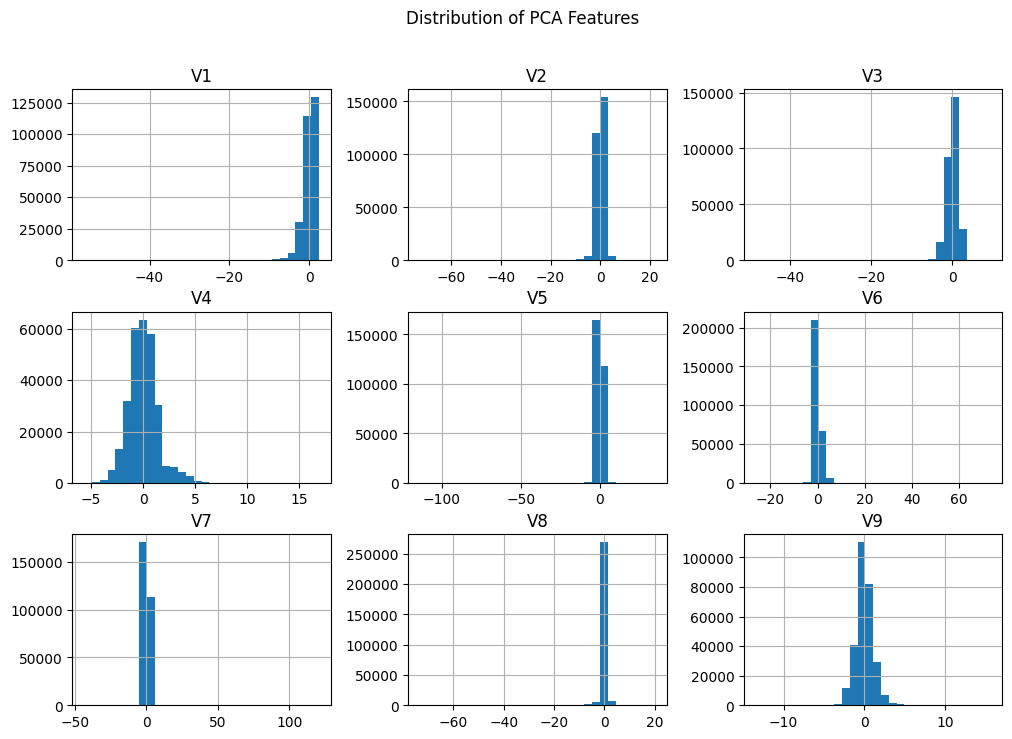

In [53]:
df.iloc[:,1:10].hist(figsize=(12,8), bins=30)

plt.suptitle("Distribution of PCA Features")

plt.show()

The distribution plots illustrate the statistical behavior of key features for fraudulent and non-fraudulent transactions. Observable differences in distributions suggest that certain features capture distinct transaction patterns, which can be leveraged by machine learning models to improve classification performance.

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale Time and Amount
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

In [55]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # VERY IMPORTANT (keeps class ratio)
)

The dataset was divided into training and testing subsets to evaluate model generalization. The training set is used to learn patterns, while the test set provides an unbiased evaluation of model performance on unseen data, ensuring that the model does not overfit.

In [56]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:\n", y_train.value_counts())

After SMOTE:
 Class
0    227451
1    227451
Name: count, dtype: int64


Feature scaling was applied to normalize the range of input variables, ensuring that all features contribute equally during model training. This is particularly important for distance-based and gradient-based algorithms, as unscaled data can lead to biased learning and slower convergence.

#After SMOTE Distribution

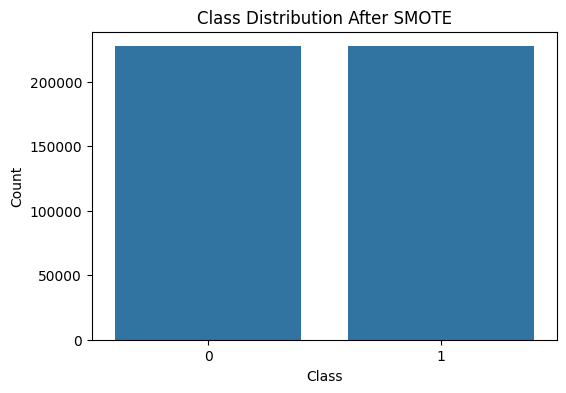

In [57]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train)

plt.title("Class Distribution After SMOTE")

plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

Synthetic Minority Oversampling Technique (SMOTE) was applied to address class imbalance by generating synthetic samples of the minority (fraud) class. This helps the model learn decision boundaries more effectively and improves its ability to detect fraudulent transactions without being biased toward the majority class.

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training KNN...
Training XGBoost...


Machine learning models were trained to classify transactions as fraudulent or legitimate. Logistic Regression serves as a baseline model due to its simplicity and interpretability. Additional models (if used) provide comparative insights into performance across different learning algorithms.

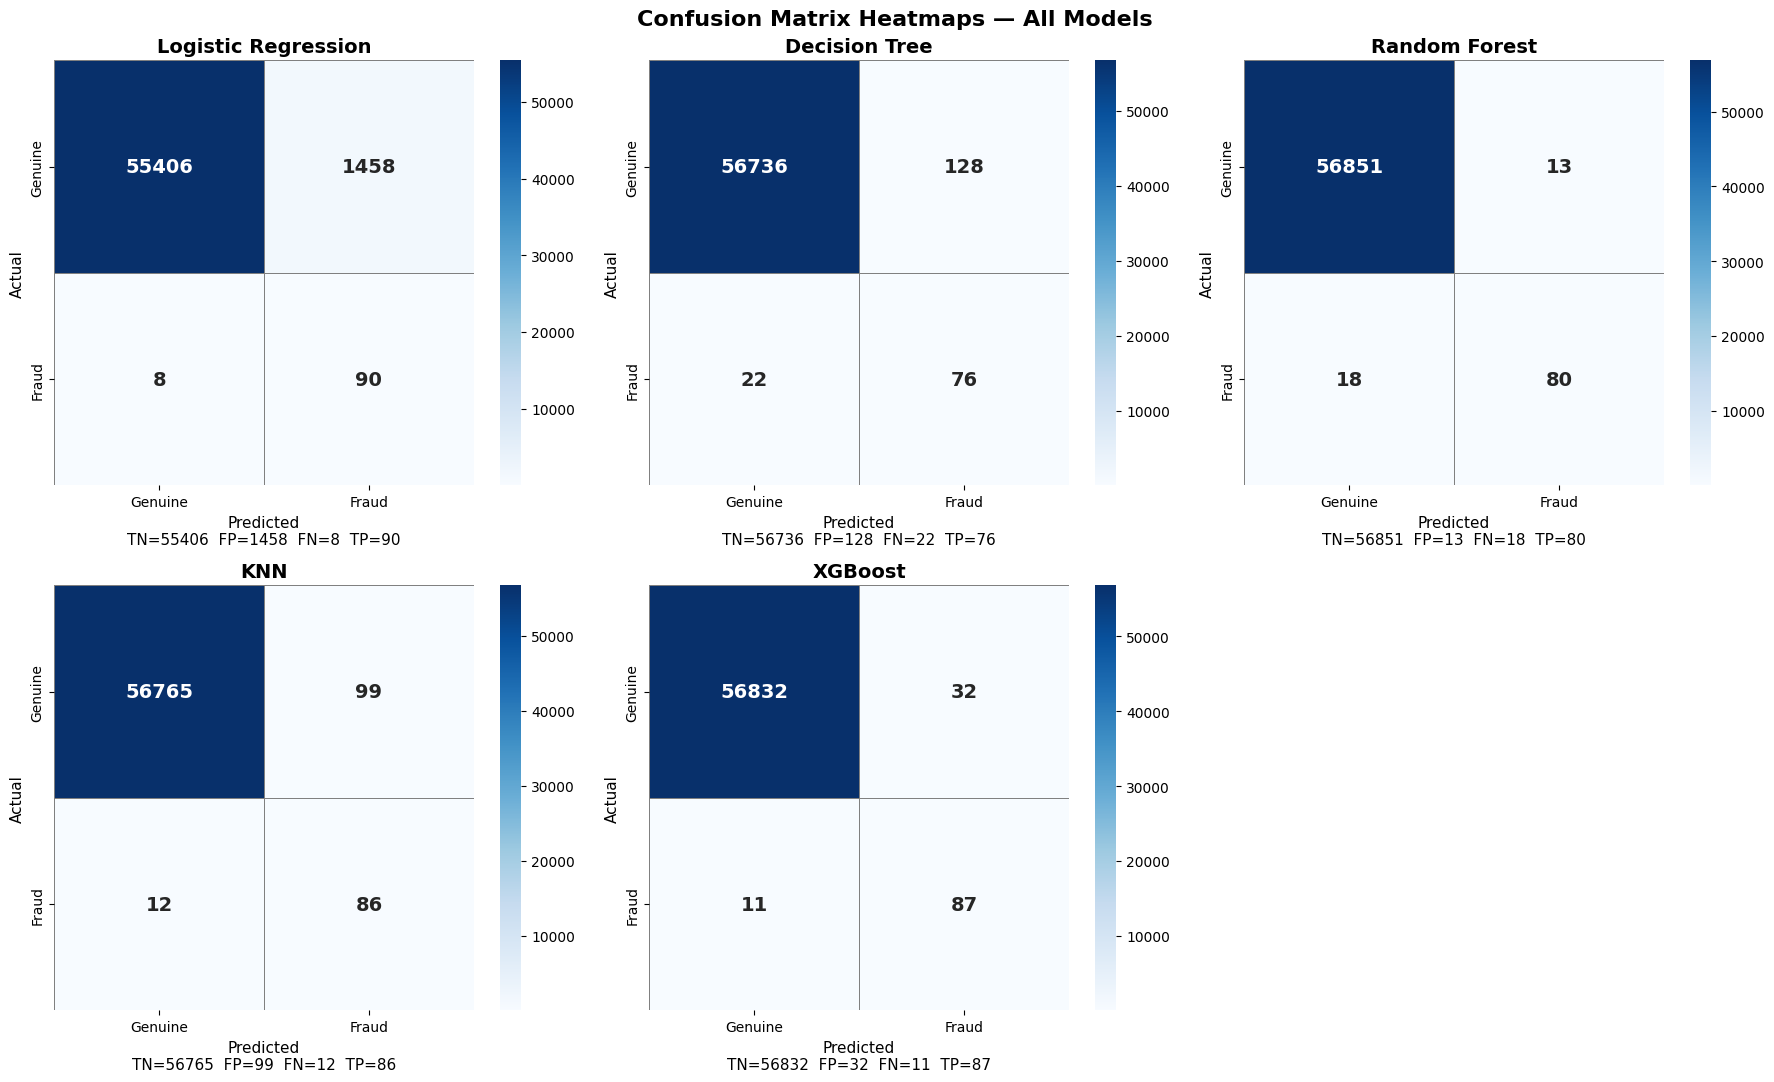

In [59]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

class_labels = ['Genuine', 'Fraud']

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    ax = axes[idx]
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels,
        linewidths=0.5,
        linecolor='gray',
        annot_kws={"size": 14, "weight": "bold"},
        ax=ax
    )

    ax.set_title(f"{name}", fontsize=14, fontweight='bold')
    ax.set_xlabel(f"Predicted\nTN={tn}  FP={fp}  FN={fn}  TP={tp}", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)

axes[5].set_visible(False)

fig.suptitle("Confusion Matrix Heatmaps — All Models", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

The confusion matrix provides a detailed breakdown of classification performance, including true positives, true negatives, false positives, and false negatives. In fraud detection, minimizing false negatives is critical, as undetected fraudulent transactions can lead to significant financial losses.

In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [61]:
import pandas as pd

results = []

for name, model in trained_models.items():
    metrics = evaluate_model(model)
    metrics["Model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Model
4,0.999245,0.731092,0.887755,0.801843,0.979159,XGBoost
0,0.974264,0.058140,0.918367,0.109356,0.969848,Logistic Regression
2,0.999456,0.860215,0.816327,0.837696,0.963079,Random Forest
3,0.998051,0.464865,0.877551,0.607774,0.953588,KNN
1,0.997367,0.372549,0.775510,0.503311,0.886630,Decision Tree


Multiple evaluation metrics were used to assess model performance. While accuracy provides an overall measure, precision and recall are more important in imbalanced datasets. Recall is particularly critical in fraud detection, as it measures the model’s ability to correctly identify fraudulent transactions. The F1-score balances precision and recall, offering a comprehensive performance metric.

#Model Comparison Graph

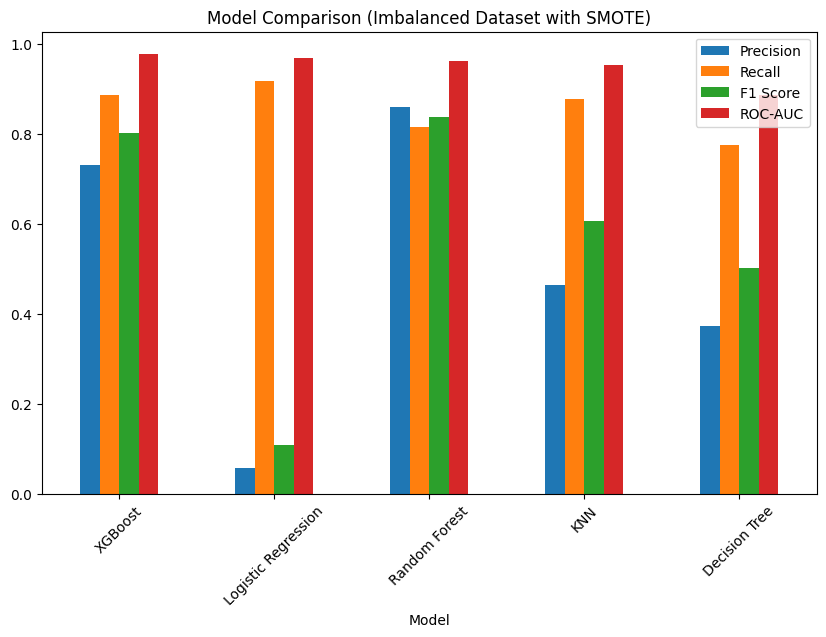

In [62]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[["Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison (Imbalanced Dataset with SMOTE)")
plt.xticks(rotation=45)
plt.show()

Comparative analysis of multiple models highlights differences in performance across evaluation metrics. This allows identification of the most suitable model for fraud detection, balancing sensitivity (recall) and precision to minimize both missed fraud cases and false alarms.

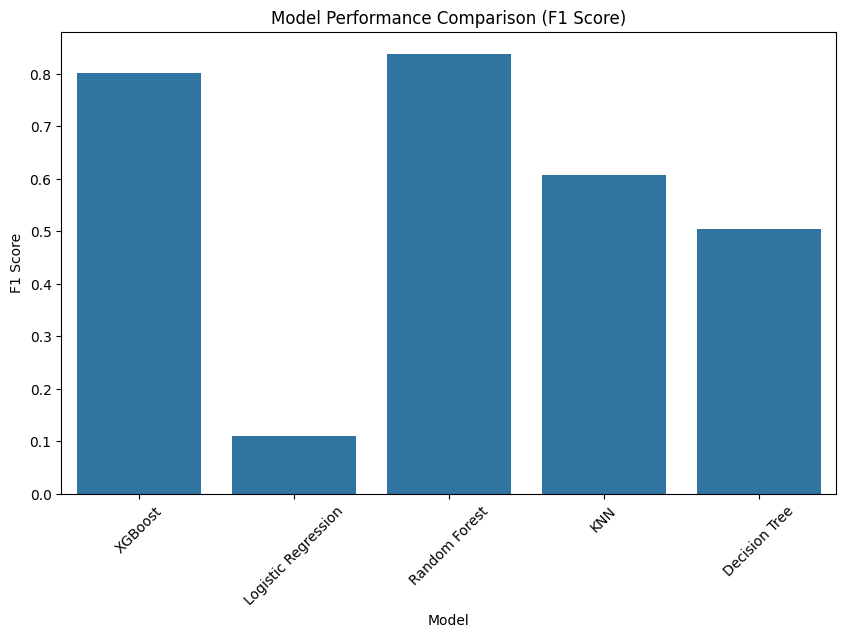

In [63]:
plt.figure(figsize=(10,6))

sns.barplot(data=results_df, x="Model", y="F1 Score")

plt.title("Model Performance Comparison (F1 Score)")

plt.xticks(rotation=45)

plt.show()

#Metrics Comparison Heatmap

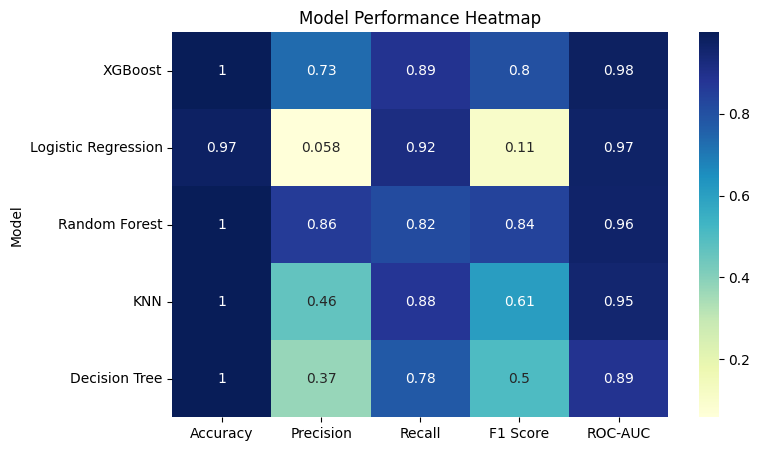

In [64]:
plt.figure(figsize=(8,5))

sns.heatmap(
    results_df.set_index("Model"),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Model Performance Heatmap")

plt.show()

In [65]:
from sklearn.metrics import classification_report

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.89      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.94      0.90     56962
weighted avg       1.00      1.00      1.00     56962



#Confusion Matrix Heatmap of best model


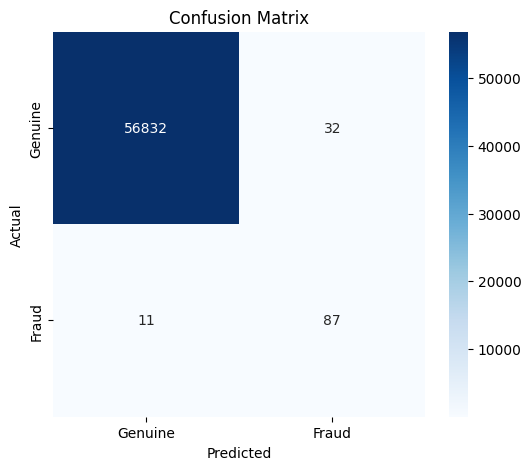

In [66]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Genuine','Fraud'],
            yticklabels=['Genuine','Fraud'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [67]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: XGBoost


#ROC Curve

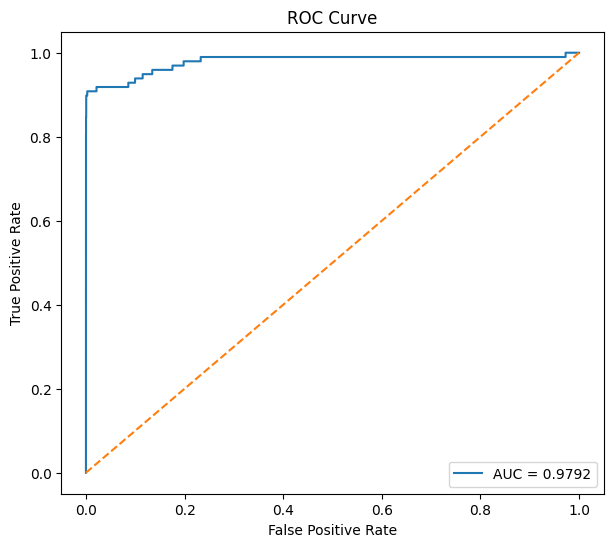

In [68]:
from sklearn.metrics import roc_curve, auc

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

The ROC curve evaluates the trade-off between true positive rate and false positive rate across different thresholds. A higher area under the curve (AUC) indicates better model discrimination capability, demonstrating the model’s effectiveness in distinguishing between fraudulent and legitimate transactions.

#Precision-Recall Curve

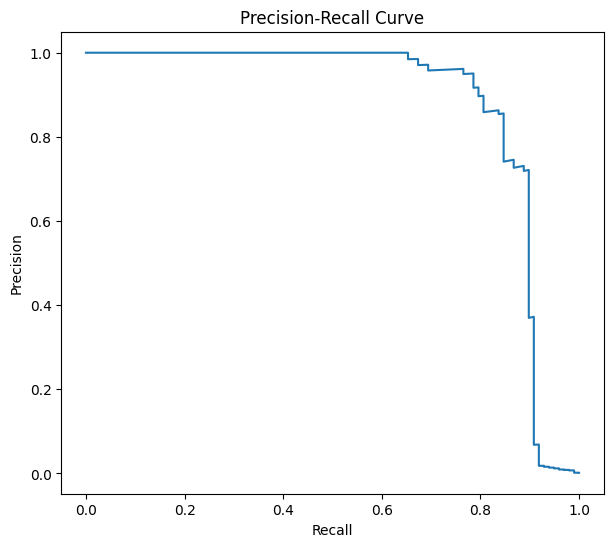

In [69]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(recall, precision)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()

The Precision-Recall curve is particularly informative for imbalanced datasets, as it focuses on the performance of the minority class. A higher area under this curve indicates that the model maintains good precision while achieving high recall, which is essential for reliable fraud detection.